# **Gráfico das Estações de Teste**

In [2]:
from google.colab import drive
# Tenta desmontar o Drive para garantir uma nova conexão limpa
try:
    drive.flush_and_unmount()
except:
    pass
# Monta o Drive novamente. Você deve ver um link e pedir a permissão.
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


--- 1. CARREGAMENTO DE DADOS ---
Digite o nome do arquivo Excel (Ex: Coletas.xlsx): Media_grafico.xlsx
Procurando arquivo em: /content/drive/MyDrive/Colab Notebooks/Projeto_dissertacao/Media_grafico.xlsx

ATENÇÃO: Se as colunas estiverem como 'Unnamed', o cabeçalho PODE NÃO ESTAR na primeira linha.
Qual é o número da linha (começando em 1) que contém o cabeçalho no Excel? (Pressione Enter para linha 1): Media_grafico.xlsx
Tentando carregar o Excel usando a linha 1 como cabeçalho...
✅ Arquivo 'Media_grafico.xlsx' carregado com sucesso.
AVISO: Removidas colunas vazias iniciais/intermediárias: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5']

--- PRÉ-VISUALIZAÇÃO DOS DADOS LIDOS ---
Colunas lidas (após limpeza de espaços): ['Data', 'Temperatura', 'Umidade', 'Local']
Se os nomes esperados não aparecerem, tente novamente com outro número de linha.
| Data                | Temperatura   | Umidade   | Local   |
|:--------------------|:--------------|:-------

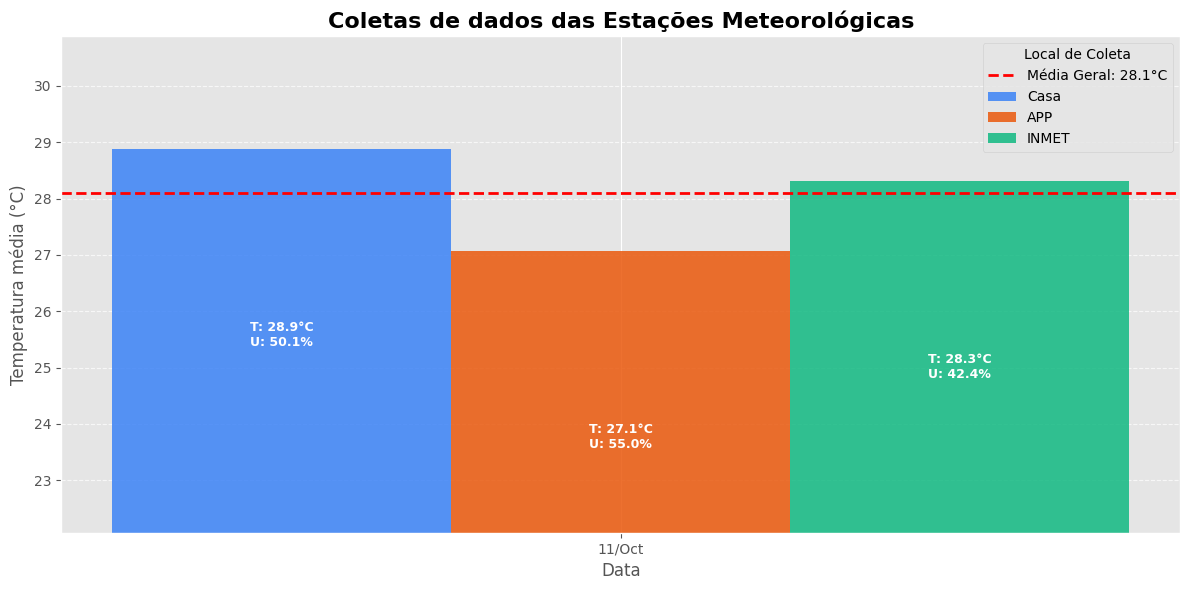


--- ANÁLISE ESTATÍSTICA DE ERRO (Referência: INMET) ---
| Métrica          | Fonte         |    MAE |   RMSE |   BIAS |
|:-----------------|:--------------|-------:|-------:|-------:|
| Temperatura (°C) | Casa vs INMET |  0.570 |  0.570 |  0.570 |
| Temperatura (°C) | APP vs INMET  |  1.250 |  1.250 | -1.250 |
| Umidade (%)      | Casa vs INMET |  7.680 |  7.680 |  7.680 |
| Umidade (%)      | APP vs INMET  | 12.600 | 12.600 | 12.600 |

Interpretação:
 - MAE (Mean Absolute Error): Erro médio absoluto. Quanto mais próximo de zero, melhor.
 - RMSE (Root Mean Square Error): Penaliza erros maiores. Quanto mais próximo de zero, melhor.
 - BIAS (Mean Error): Média do erro. Positivo indica que a fonte tende a superestimar o INMET, negativo indica subestimar.

--- Dados Carregados do Excel ---
| Data                |   Temperatura |   Umidade | Local   |
|:--------------------|--------------:|----------:|:--------|
| 2025-10-11 00:00:00 |         28.89 |     50.08 | Casa    |
| 2025-10-11 00:

In [4]:
# ====================================================================
# Gerador de Gráfico de Coletas Meteorológicas e Análise Estatística
# Linguagens: Python (Pandas, Matplotlib e NumPy)
# Objetivo: Criar gráfico de barras agrupadas e calcular MAE, RMSE e BIAS
#           comparando as fontes de dados ('Casa' e 'APP') com a referência ('INMET').
# ====================================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os # Necessário para checar a existência do arquivo
from typing import Optional, List

# --- CONFIGURAÇÃO DE DIRETÓRIO (AJUSTADO PARA AMBIENTES COMO COLAB/JUPYTER) ---
# Se o script for executado no Google Colab ou Jupyter com Drive montado, use esta pasta.
# Para execução local, defina como "" ou remova se o arquivo estiver no diretório atual.
PASTA_DRIVE = '/content/drive/MyDrive/Colab Notebooks/Projeto_dissertacao'

# --- FUNÇÃO DE DIAGNÓSTICO ---
def verificar_arquivos_drive(caminho_pasta: str, nome_arquivo: str):
    """Verifica e lista os arquivos no diretório especificado para diagnóstico."""
    print("\n--- DIAGNÓSTICO DO DIRETÓRIO ---")

    # 1. Verifica se a pasta existe
    if not os.path.isdir(caminho_pasta):
        print(f"DIRETÓRIO INEXISTENTE: A pasta '{caminho_pasta}' não foi encontrada.")
        print("VERIFIQUE: 1. Se o Drive está montado. 2. A ortografia da PASTA_DRIVE.")
        return

    # 2. Lista os arquivos
    try:
        arquivos = os.listdir(caminho_pasta)

        if nome_arquivo in arquivos:
            print(f"✅ ARQUIVO ENCONTRADO NA PASTA! O nome do arquivo '{nome_arquivo}' foi CORRETAMENTE reconhecido.")
        else:
            print(f"❌ ARQUIVO NÃO VISTO: O arquivo '{nome_arquivo}' não está na lista de arquivos.")

        print(f"Arquivos presentes na pasta '{caminho_pasta}':")
        # Limita a 10 arquivos para evitar poluição no console
        for arquivo in arquivos[:10]:
            print(f"  - {arquivo}")

        if len(arquivos) > 10:
            print(f"  ... e mais {len(arquivos) - 10} arquivos.")

    except Exception as e:
        print(f"ERRO ao listar arquivos (Permissão/Caminho): {e}")

# --- 1. CARREGAMENTO E ESTRUTURAÇÃO DOS DADOS DO EXCEL ---

def carregar_dados_excel() -> Optional[pd.DataFrame]:
    """Solicita o nome do arquivo Excel, carrega os dados e lida com o cabeçalho."""
    print("--- 1. CARREGAMENTO DE DADOS ---")

    df_to_process: Optional[pd.DataFrame] = None

    # Solicita o nome do arquivo ao usuário
    NOME_ARQUIVO_EXCEL = input("Digite o nome do arquivo Excel (Ex: Coletas.xlsx): ").strip()

    # Adiciona a extensão padrão se não foi fornecida
    if not NOME_ARQUIVO_EXCEL.lower().endswith(('.xlsx', '.xls')):
        print("AVISO: Adicionando extensão .xlsx (pode ser necessário mudar para .xls).")
        if '.' not in NOME_ARQUIVO_EXCEL:
            NOME_ARQUIVO_EXCEL += '.xlsx'

    # Constrói o caminho completo do arquivo
    CAMINHO_COMPLETO = os.path.join(PASTA_DRIVE, NOME_ARQUIVO_EXCEL)

    print(f"Procurando arquivo em: {CAMINHO_COMPLETO}")


    if not os.path.exists(CAMINHO_COMPLETO):
        print(f"\nERRO: Arquivo '{NOME_ARQUIVO_EXCEL}' não encontrado.")
        print(f"Caminho verificado: {CAMINHO_COMPLETO}")
        print("Certifique-se de que o Google Drive está montado e o nome do arquivo está correto.")

        # CHAMADA DE DIAGNÓSTICO AQUI
        verificar_arquivos_drive(PASTA_DRIVE, NOME_ARQUIVO_EXCEL)

        # --- BLOC DE FALLBACK (PARA TESTE) ---
        print("--- Usando dados de TESTE para demonstração do gráfico e das métricas. ---")
        df_to_process = pd.DataFrame({
            'Data': ['2025-10-11', '2025-10-11', '2025-10-11', '2025-10-12', '2025-10-12', '2025-10-12',
                     '2025-10-13', '2025-10-13', '2025-10-13'],
            'Local': ['Casa', 'APP', 'INMET', 'Casa', 'APP', 'INMET', 'Casa', 'APP', 'INMET'],
            # Diferenças sutis para o teste
            'Temperatura': [28.89, 27.07, 28.32, 29.15, 27.50, 28.90, 30.00, 29.50, 29.80],
            'Umidade': [50.08, 55.00, 42.40, 48.50, 52.00, 40.00, 55.00, 58.00, 53.00]
        })
        # ------------------------------------

    else:
        try:
            # Novo input para tentar corrigir a linha do cabeçalho
            print("\nATENÇÃO: Se as colunas estiverem como 'Unnamed', o cabeçalho PODE NÃO ESTAR na primeira linha.")
            linha_cabecalho_str = input("Qual é o número da linha (começando em 1) que contém o cabeçalho no Excel? (Pressione Enter para linha 1): ").strip() or '1'

            try:
                # O parâmetro header no Pandas é baseado no índice 0 (0 para linha 1, 1 para linha 2, etc.)
                header_index = int(linha_cabecalho_str) - 1
            except ValueError:
                header_index = 0

            print(f"Tentando carregar o Excel usando a linha {header_index + 1} como cabeçalho...")

            # Tenta carregar o Excel com a linha de cabeçalho especificada
            df_to_process = pd.read_excel(CAMINHO_COMPLETO, sheet_name=0, header=header_index)
            print(f"✅ Arquivo '{NOME_ARQUIVO_EXCEL}' carregado com sucesso.")

            # --- REMOÇÃO DE COLUNAS VAZIAS (Unnamed: X) ---
            colunas_para_remover = [col for col in df_to_process.columns if str(col).startswith('Unnamed:')]
            if colunas_para_remover:
                df_to_process.drop(columns=colunas_para_remover, inplace=True)
                print(f"AVISO: Removidas colunas vazias iniciais/intermediárias: {colunas_para_remover}")
            # ---------------------------------------------------

            # --- CORREÇÃO DE ESPAÇOS: Remove espaços em branco iniciais/finais dos nomes das colunas ---
            # Isso corrige problemas como 'Local ' sendo lido em vez de 'Local'
            df_to_process.columns = df_to_process.columns.str.strip()
            # ------------------------------------------------------------------------------------------

            # --- NOVO DIAGNÓSTICO DE COLUNAS LIDA ---
            print("\n--- PRÉ-VISUALIZAÇÃO DOS DADOS LIDOS ---")
            print(f"Colunas lidas (após limpeza de espaços): {list(df_to_process.columns)}")
            print("Se os nomes esperados não aparecerem, tente novamente com outro número de linha.")
            # Se o cabeçalho for muito grande, limitamos a 5 colunas
            preview_df = df_to_process.head()
            preview_cols = preview_df.columns[:5]
            print(preview_df[preview_cols].to_markdown(index=False, numalign="left"))
            print("--------------------------------------")
            # ----------------------------------------

        except Exception as e:
            print(f"\nERRO ao processar o arquivo Excel (Carregamento com cabeçalho): {e}")
            return None # Falha fatal no carregamento

    if df_to_process is None:
        return None

    # Validação das colunas esperadas (Executa para Excel e Fallback)
    colunas_esperadas = ['Data', 'Local', 'Temperatura', 'Umidade']

    # Verifica se as colunas esperadas estão presentes
    if not all(col in df_to_process.columns for col in colunas_esperadas):
        print("\nERRO: O DataFrame deve conter as seguintes colunas exatas:")
        print(f"      {colunas_esperadas}")
        print(f"      Colunas encontradas: {list(df_to_process.columns)}")
        print("\nSUGESTÃO: Verifique se a linha do cabeçalho está correta ou se os nomes das colunas estão exatos (incluindo letras maiúsculas/minúsculas).")
        return None # Retorna None se as colunas não corresponderem

    # Limpeza e conversão de tipos (EXECUTA PARA EXCEL E FALLBACK)
    df_to_process['Data'] = pd.to_datetime(df_to_process['Data'], errors='coerce').dt.normalize()
    df_to_process['Temperatura'] = pd.to_numeric(df_to_process['Temperatura'], errors='coerce')
    df_to_process['Umidade'] = pd.to_numeric(df_to_process['Umidade'], errors='coerce')

    # Remove linhas com valores nulos após a conversão
    df_to_process.dropna(subset=['Data', 'Local', 'Temperatura', 'Umidade'], inplace=True)

    if df_to_process.empty:
        print("ERRO: O DataFrame está vazio após a limpeza. Verifique os dados no Excel.")
        return None

    print(f"DataFrame pronto para análise (Total de {len(df_to_process)} linhas).")
    return df_to_process


# --- NOVO: FUNÇÃO PARA CALCULAR MAE, RMSE e BIAS ---
def calcular_metricas_erro(df_pivot: pd.DataFrame, metric_col: str) -> pd.DataFrame:
    """
    Calcula MAE, RMSE e BIAS para 'Casa' e 'APP' em relação a 'INMET'
    para uma coluna de métrica específica (Temperatura ou Umidade).
    """
    # 1. Alinhamento: Garantir que apenas datas com 'INMET', 'Casa' e 'APP' existam.
    # Usamos .dropna() no subset das colunas de interesse.

    comparacao_cols = ['INMET', 'Casa', 'APP']
    # Se alguma coluna (Casa, APP, INMET) estiver faltando, não é possível comparar
    if not all(col in df_pivot.columns for col in comparacao_cols):
        print(f"AVISO: Colunas de comparação {comparacao_cols} incompletas para {metric_col}.")
        return pd.DataFrame()

    df_metrics = df_pivot[comparacao_cols].dropna()

    if df_metrics.empty:
        return pd.DataFrame() # Retorna vazio se não houver dados comparáveis

    y_true = df_metrics['INMET'].values

    results: List[dict] = []

    # 2. Comparação Casa vs INMET
    y_pred_casa = df_metrics['Casa'].values
    # Diferença (Predição - Verdadeiro): Positivo = sobrestima, Negativo = subestima
    diff_casa = y_pred_casa - y_true

    mae_casa = np.mean(np.abs(diff_casa))
    rmse_casa = np.sqrt(np.mean(diff_casa**2))
    bias_casa = np.mean(diff_casa)

    results.append({
        'Métrica': metric_col,
        'Fonte': 'Casa vs INMET',
        'MAE': mae_casa,
        'RMSE': rmse_casa,
        'BIAS': bias_casa
    })

    # 3. Comparação APP vs INMET
    y_pred_app = df_metrics['APP'].values
    diff_app = y_pred_app - y_true

    mae_app = np.mean(np.abs(diff_app))
    rmse_app = np.sqrt(np.mean(diff_app**2))
    bias_app = np.mean(diff_app)

    results.append({
        'Métrica': metric_col,
        'Fonte': 'APP vs INMET',
        'MAE': mae_app,
        'RMSE': rmse_app,
        'BIAS': bias_app
    })

    return pd.DataFrame(results)
# ----------------------------------------------------


# --- INÍCIO DA EXECUÇÃO PRINCIPAL ---
df = carregar_dados_excel()

# Se o DataFrame for None (em caso de erro de coluna ou carregamento fatal),
# o script não deve tentar plotar ou calcular métricas.
if df is None or df.empty:
    print("Não foi possível gerar o gráfico ou calcular métricas devido a dados inválidos ou ausentes.")
    # Não usamos exit() pois o ambiente do notebook não gosta, mas garantimos que a execução pare aqui
    raise SystemExit(0)

# --- 2. PREPARAÇÃO DOS DADOS PARA O GRÁFICO E MÉTRICAS (Pivot/Transformação) ---

# Pivotar o DataFrame para Temperatura
df_temp_pivot = df.pivot(index='Data', columns='Local', values='Temperatura')

# Pivotar o DataFrame para Umidade (usado para rótulos e métricas)
df_umid_pivot = df.pivot(index='Data', columns='Local', values='Umidade')

# NOVO: Calcular Métricas de Erro
metricas_temp = calcular_metricas_erro(df_temp_pivot, 'Temperatura (°C)')
metricas_umid = calcular_metricas_erro(df_umid_pivot, 'Umidade (%)')
df_metricas_final = pd.concat([metricas_temp, metricas_umid], ignore_index=True)


# NOVO: Limitar a visualização aos últimos 7 dias para clareza
MAX_DIAS_VISUALIZACAO = 7
if len(df_temp_pivot) > MAX_DIAS_VISUALIZACAO:
    print(f"AVISO: Limitando a visualização aos últimos {MAX_DIAS_VISUALIZACAO} dias de coleta ({len(df_temp_pivot)} dias encontrados).")
    df_temp_pivot = df_temp_pivot.tail(MAX_DIAS_VISUALIZACAO)
    df_umid_pivot = df_umid_pivot.tail(MAX_DIAS_VISUALIZACAO)

# Obter os rótulos do eixo X (Datas formatadas: DD/MMM)
# Ex: 2025-10-11 -> 11/Out
df_temp_pivot.index = df_temp_pivot.index.to_series().dt.strftime('%d/%b').str.replace('.', '')

# Cores e Posições (Garantir ordem fixa)
locais = ['Casa', 'APP', 'INMET']
cores = {
    'Casa': '#3b82f6',     # Azul (blue-500)
    'APP': '#ea580c',      # Laranja (orange-600)
    'INMET': '#10b981'     # Verde (emerald-500)
}

# --- 3. GERAÇÃO DO GRÁFICO DE BARRAS AGRUPADAS ---

# Calcular a média geral de temperatura para a linha de tendência
media_geral_temp = df['Temperatura'].mean()
print(f"\nMédia Geral de Temperatura Calculada: {media_geral_temp:.2f}°C")


# Configuração do gráfico
fig, ax = plt.subplots(figsize=(12, 6))
plt.style.use('ggplot') # Estilo visual moderno e limpo

largura_barra = 0.25 # Largura de cada barra
x_indices = np.arange(len(df_temp_pivot.index)) # Posições no eixo X (um índice por data)

# 3.0. Linha de Tendência (Média Geral de Temperatura)
ax.axhline(
    media_geral_temp,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Média Geral: {media_geral_temp:.1f}°C'
)

# 3.1. Desenho das Barras e Rótulos (Temperatura)
for i, local in enumerate(locais):
    # Pula se o local não tiver dados para nenhuma data no DataFrame pivotado
    if local not in df_temp_pivot.columns:
        continue

    # Calcula a posição da barra para garantir que fiquem lado a lado
    posicao_x = x_indices + (i - 1) * largura_barra

    # Desenha a barra (usando Temperatura como altura)
    barras = ax.bar(
        posicao_x,
        df_temp_pivot[local].values,
        largura_barra,
        label=local,
        color=cores[local],
        alpha=0.85 # Leve transparência
    )

    # 3.2. Rótulos de Temperatura (°C) e Umidade (%) dentro das barras
    for barra, temp_valor, umid_valor in zip(barras, df_temp_pivot[local].values, df_umid_pivot[local].values):
        # Evita plotar rótulos se houver valores nulos (NaN)
        if not pd.isna(temp_valor) and not pd.isna(umid_valor):
            # Formata os rótulos de temperatura e umidade em duas linhas
            # T: Temperatura (°C) / U: Umidade (%)
            label_text = f'T: {temp_valor:.1f}°C\nU: {umid_valor:.1f}%'

            # Posição Y padrão (dentro da barra, mais alto para caber 2 linhas)
            text_y_position = barra.get_height() - 3.5
            label_color = 'white'

            # Ajuste dinâmico da posição Y e cor do texto para barras baixas (saem de dentro da barra)
            if barra.get_height() < 20:
                text_y_position = barra.get_height() + 0.5
                label_color = 'black'

            ax.text(
                barra.get_x() + barra.get_width() / 2, # Posição X (centro da barra)
                text_y_position, # Posição Y
                label_text,
                ha='center', # Alinhamento horizontal (centralizado)
                color=label_color, # Cor do texto (para contraste com a barra)
                fontsize=9, # Fonte ligeiramente menor
                fontweight='bold'
            )


# --- 4. AJUSTES FINOS DO GRÁFICO ---

# Título Principal
ax.set_title('Coletas de dados das Estações Meteorológicas', fontsize=16, fontweight='bold')

# Rótulos dos Eixos
ax.set_ylabel('Temperatura média (°C)', fontsize=12)
ax.set_xlabel('Data', fontsize=12)

# Configurar o Eixo X para mostrar as datas abreviadas
ax.set_xticks(x_indices)
ax.set_xticklabels(df_temp_pivot.index)

# Legenda: Inclui a média geral
ax.legend(title='Local de Coleta')

# Linhas de grade (opcional)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar um pequeno espaço extra acima do gráfico (ajustado para a linha de média e rótulos)
y_min_val = df_temp_pivot.values.min() if not df_temp_pivot.empty else 0
y_max_val = df_temp_pivot.values.max() if not df_temp_pivot.empty else 10
ax.set_ylim(bottom=y_min_val - 5, top=y_max_val + 2) # Adicionamos mais 2 de espaço no topo

# Mostrar o gráfico
plt.tight_layout() # Ajusta automaticamente o layout
plt.show()

# --- 5. VISUALIZAÇÃO DOS DADOS ESTATÍSTICOS ---
print("\n" + "="*80)
print("--- ANÁLISE ESTATÍSTICA DE ERRO (Referência: INMET) ---")

if not df_metricas_final.empty:
    print(df_metricas_final.to_markdown(
        index=False,
        floatfmt=(".0f", ".0f", ".3f", ".3f", ".3f") # Formata as 3 métricas com 3 casas decimais
    ))
    print("\nInterpretação:")
    print(" - MAE (Mean Absolute Error): Erro médio absoluto. Quanto mais próximo de zero, melhor.")
    print(" - RMSE (Root Mean Square Error): Penaliza erros maiores. Quanto mais próximo de zero, melhor.")
    print(" - BIAS (Mean Error): Média do erro. Positivo indica que a fonte tende a superestimar o INMET, negativo indica subestimar.")
else:
    print("AVISO: Não foi possível calcular as métricas de erro. Certifique-se de que há dados 'INMET', 'Casa' e 'APP' para as mesmas datas.")

print("="*80)
print("\n--- Dados Carregados do Excel ---")
print(df.head().to_markdown(index=False, floatfmt=".2f"))
print(f"\nDataFrame final com {len(df)} pontos de dados (Plotando os últimos {len(df_temp_pivot)} dias).")
print("\nNota: O gráfico agora inclui uma linha de tendência da Média Geral e exibe T/U dentro das barras.")
